# Trabalho 2

In [1]:
from pose import Pose
from angle import Angle
from control import VelocityControl
from robot import Robot
from distributions import GaussianDistribution
from maps import LandmarkMap, Landmark
from sensor import Camera, DetectedFeature

import matplotlib.pyplot as plt
import numpy as np

/home/jtu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


#TODO: explain better why, make nice plots

### Note:
the `landmark_model_known_correspondence` has been adapted to take into consideration the orientation of the hypothesis by subtracting `x_hypothesis.th` to the estimated `phi_hat` otherwise it is implicitly assumed that the hypothesis has a zero orientation. Implementing the algorithm without this fix leads to wrong representations of the probability distribution, should the orientation of the robot not be `0`.

In [44]:
def landmark_model_known_correspondence(feature: DetectedFeature, correspondence: int, x_hypothesis: Pose, map: LandmarkMap, sigmas = [0.1, 0.1, 0.1]):
    [sigma_r, sigma_phi, sigma_s] = sigmas

    l = map.landmarks[correspondence]
    m_x, m_y, m_s = l.pos.x, l.pos.y, l.signture

    dx = m_x - x_hypothesis.x
    dy = m_y - x_hypothesis.y

    r_hat = np.sqrt(dx**2 + dy**2)
    phi_hat = Angle.atan2(dy, dx) - x_hypothesis.th

    return (
        GaussianDistribution(sigma_r**2).prob(feature.r - r_hat)
        * GaussianDistribution(sigma_phi**2).prob((feature.phi - phi_hat).rad) 
        #* GaussianDistribution(sigma_s**2).prob(feature.s - m_s)
    )


def plotLandmarkMeasurmentProbabilityDistribution(
        ax: plt.Axes, 
        fs: list[DetectedFeature],
        cs: list[int],
        m: LandmarkMap,
        sigmas: tuple[float, float, float] = (0.5, 0.5, 0.1), 
        resolution: float = 0.08, 
        angular_resolution: float = 360,
        x_interval: list[float, float] = [-5., 5.], 
        y_interval: list[float, float] = [-5., 5.],
        hypothesys_th_offset: Angle = Angle(0)
    ):

    #Draw probability distribution
    nx = int((x_interval[1] -  x_interval[0] + resolution) / resolution)
    ny = int((y_interval[1] -  y_interval[0] + resolution) / resolution)

    probability_distribution =  np.zeros((ny, nx))
    for x_idx, x in enumerate(np.linspace(x_interval[0], x_interval[1], num = nx)):
        for y_idx, y in enumerate(np.linspace(y_interval[0], y_interval[1], num = ny)):

            th = hypothesys_th_offset.deg
            while th < 360 + hypothesys_th_offset.deg:
                probability = 1

                x_hypothesis = Pose(x, y, Angle.from_deg(th))

                for f, c in zip(fs, cs):
                    probability *= landmark_model_known_correspondence(f, c, x_hypothesis, m, sigmas)
                
                probability_distribution[y_idx, x_idx] += probability

                th += angular_resolution

    ax.imshow(probability_distribution, cmap='Blues', extent=[x_interval[0], x_interval[1], y_interval[0], y_interval[1]], origin='lower')

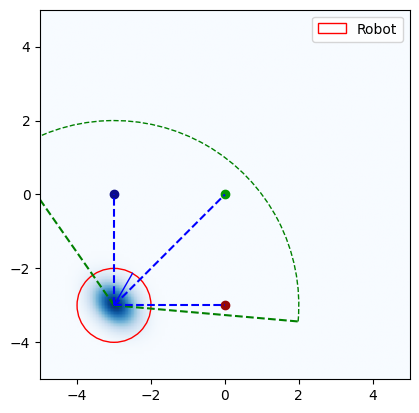

In [55]:
m = LandmarkMap([
    Landmark(Pose(0, 0, Angle(0)), 0),
    Landmark(Pose(-3, 0, Angle(0)), 1),
    Landmark(Pose(0, -3, Angle(0)), 2),
])

r = Robot(Pose(-3,-3,Angle(np.pi/3)))
c = Camera(Pose(0,0,Angle(0)),robot_pose=r.pos, field_of_veiw=Angle.from_deg(130))
c.getReading(m,detection_noise=False)

f = plt.figure()

ax = f.gca()

m.draw(ax)
r.draw(ax)
c.draw(ax, draw_sensor_readings=True)

plotLandmarkMeasurmentProbabilityDistribution(ax, c.reading['features'], c.reading['correspondences'], m, hypothesys_th_offset = r.pos.th)